# Seminar: Vector Quantization

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

device = 'cuda' if torch.cuda.is_available() else 'cpu'

### Dataset

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

def create_educational_datasets(n_samples):
    """Create different 2D patterns that reveal quantization properties"""
    datasets = {}

    # 1. Well-separated clusters (easy case)
    # Create a GMM with specific parameters
    gmm = GaussianMixture(n_components=3, random_state=42)

    # Manually set parameters to create interesting structure
    gmm.means_ = np.array([[2, 1.8], [-1.8, -2.2], [-2.2, 1.9]])  # Slightly offset
    gmm.covariances_ = np.array([
        [[0.3, 0.15], [0.15, 0.2]],    # Elliptical, correlated
        [[0.2, -0.1], [-0.1, 0.3]],    # Rotated ellipse
        [[0.1, 0], [0, 0.1]]           # Small spherical
    ])
    gmm.weights_ = np.array([0.5, 0.3, 0.2])  # Uneven weights
    gmm.precisions_cholesky_ = np.linalg.cholesky(np.linalg.inv(gmm.covariances_))

    # Generate data
    gmm_data, gmm_labels = gmm.sample(n_samples)
    np.random.shuffle(gmm_data)
    datasets['easy_case'] = gmm_data.astype(np.float32)

    # 2. Continuous distribution (hard case)
    datasets['hard_case'] = np.random.multivariate_normal(
        [0, 0], [[2, 0.5], [0.5, 1]], n_samples
    ).astype(np.float32)

    # 3. Ring structure (challenging case)
    theta = np.random.uniform(0, 2*np.pi, n_samples)
    r = np.random.normal(3, 0.3, n_samples)
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    datasets['challenging_case'] = np.column_stack([x, y]).astype(np.float32)

    return datasets

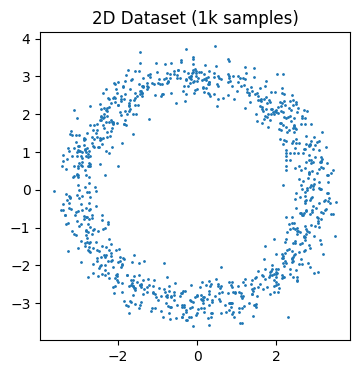

In [ ]:
# Create and plot
data = create_educational_datasets(n_samples=10000)['challenging_case']
plt.figure(figsize=(4,4))
plt.scatter(data[:1000,0], data[:1000,1], s=1)
plt.title(f"2D Dataset (1k samples)")
# plt.axis('equal')
plt.show()

dataset = TensorDataset(torch.from_numpy(data))
dataloader = DataLoader(dataset, batch_size=256, shuffle=True)

### Models

Models: Encoder & Decoder (MLP)

In [ ]:
class Encoder(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=64, latent_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim)
        )
    def forward(self, x):
        return self.net(x)  # (B, latent_dim)

class Decoder(nn.Module):
    def __init__(self, latent_dim=2, hidden_dim=64, output_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
    def forward(self, z):
        return self.net(z)  # (B, 2)

Discriminator

In [ ]:
class Discriminator(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)  # (B,)

### Quantizer

#### VQ

We want to learn:
- A **discrete bottleneck**: each input maps to a sequence of indices into a codebook
- A **reconstructive model**: minimize reconstruction error
- A **well-utilized codebook**: all codes are useful and representative

But quantization is non-differentiable.

VQ-VAE Total Loss:

$$
\mathcal{L}_{\text{VQ-VAE}} = \underbrace{\|x - D(z_q)\|^2}_{\text{Reconstruction}} + \underbrace{\| \text{sg}(z_e) - z_q \|^2}_{\text{Codebook loss}} + \underbrace{\beta \| z_e - \text{sg}(z_q) \|^2}_{\text{Commitment loss}}
$$

Where:
- $ \text{sg}(\cdot) $ = **stop-gradient** operator (no backprop through it)
- $ \beta > 0 $ = hyperparameter (typically 0.1–0.25)

If we will train only reconstruction loss:
* No gradients will pass through codebook and it will not be updated.
* Encoder will not be updated, since we can not calculate gradients of quantization block:

$$
\frac{\partial \mathcal{L}}{\partial z_e} = \frac{\partial \mathcal{L}}{\partial z_q} \cdot \frac{\partial z_q}{\partial z_e}
$$

But:
- $ \frac{\partial z_q}{\partial z_e} = 0 $ (almost everywhere)
- So $ \frac{\partial \mathcal{L}}{\partial z_e} = 0 $

That is why two additional losses are added.

1. **Codebook Loss** (Update the Codebook)

We want each codebook vector $ e_k $ to **move toward the encoder outputs** that use it.

So minimize:
$$
\mathcal{L}_{\text{codebook}} = \| \text{sg}(z_e) - z_q \|^2
$$

- $\text{sg}(z_e)$ = treat encoder output as **fixed target**
- Gradient flows **only to $ z_q $** → which comes from codebook → **codebook updates**

2. **Commitment Loss** (Train the Encoder)

We want the encoder to **commit to the codebook**, output $ z_e $ close to some $ e_k $.

So minimize:
$$
\mathcal{L}_{\text{commit}} = \| z_e - \text{sg}(z_q) \|^2
$$

- $sg(z_q)$ = treat quantized output as **fixed target**
- Gradient flows **only to $ z_e $** → **encoder updates**

Encoder outputs will force to stay near codebook vectors. This also **stabilizes training**: prevents encoder from drifting too far, making the Straight-Through Estimator (STE) approximation valid.


3. **Reconstruction Loss** (Train Decoder + (via STE) Encoder)

$$
\mathcal{L}_{\text{recon}} = \| x - D(z_q) \|^2
$$

- Gradient flows to **decoder** (directly)
- Gradient flows to **encoder** via **STE**: during backprop, $ z_q \approx z_e $, so $ \partial \mathcal{L}/\partial z_e \approx \partial \mathcal{L}/\partial z_q $

Paper: https://arxiv.org/pdf/1711.00937



This is **not derived from a probabilistic ELBO** (unlike VAEs)—it’s a **heuristic but effective** objective.

**Important Note:** VQ-VAE is **not a variational autoencoder** in the Bayesian sense—it’s a **vector-quantized autoencoder**.


In [ ]:
class VQ(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, commitment_cost):
        super(VQ, self).__init__()

        self._embedding_dim = embedding_dim
        self._num_embeddings = num_embeddings

        self._embedding = nn.Embedding(self._num_embeddings, self._embedding_dim)
        self._embedding.weight.data.uniform_(-1/self._num_embeddings, 1/self._num_embeddings)
        self._commitment_cost = commitment_cost

    def forward(self, inputs):
        # inputs: z (B, D)

        input_shape = inputs.shape

        # Calculate distances
        distances = (torch.sum(inputs**2, dim=1, keepdim=True)
                    + torch.sum(self._embedding.weight**2, dim=1)
                    - 2 * torch.matmul(inputs, self._embedding.weight.t())) # --> (B, K)

        # Encoding
        encoding_indices = torch.argmin(distances, dim=1).unsqueeze(1) # [B, 1]
        encodings = torch.zeros(encoding_indices.shape[0], self._num_embeddings, device=inputs.device)
        encodings.scatter_(1, encoding_indices, 1) # тут лежат вероятности q(z = k| x)

        # Quantize and unflatten
        quantized = torch.matmul(encodings, self._embedding.weight).view(input_shape) # --> (B, D)

        # Loss
        e_latent_loss = F.mse_loss(quantized.detach(), inputs)
        q_latent_loss = F.mse_loss(quantized, inputs.detach())
        loss = q_latent_loss + self._commitment_cost * e_latent_loss

        # Straight-through estimator: copy gradients from z to z_q
        quantized = inputs + (quantized - inputs).detach()
        avg_probs = torch.mean(encodings, dim=0)
        perplexity = torch.exp(-torch.sum(avg_probs * torch.log(avg_probs + 1e-10)))

        return loss, quantized, perplexity, encodings

#### RVQ

In [ ]:
class RVQ(nn.Module):
    def __init__(self, num_quantizers, num_embeddings, embedding_dim, commitment_cost=0.25):
        """
        Residual Vector Quantizer (RVQ)

        Args:
            num_quantizers (int): Number of VQ layers (L)
            num_embeddings (int): Codebook size per layer (K)
            embedding_dim (int): Latent dimension (D)
            commitment_cost (float): Beta for commitment loss (same for all layers)
        """
        super(RVQ, self).__init__()
        self.num_quantizers = num_quantizers
        self.layers = nn.ModuleList([
            VQ(num_embeddings, embedding_dim, commitment_cost)
            for _ in range(num_quantizers)
        ])

    def forward(self, z):
        """
        Args:
            z: continuous latent from encoder, shape (B, D)

        Returns:
            total_vq_loss: scalar
            z_q: quantized latent, shape (B, D)
            total_perplexity: average perplexity across layers
            all_encodings: list of encodings per layer (for analysis)
        """
        residual = z
        z_q_sum = torch.zeros_like(z)
        total_vq_loss = 0.0
        total_perp = 0.0
        all_encodings = []

        for i, layer in enumerate(self.layers):
            # Quantize current residual
            vq_loss, z_q_i, perplexity, encodings = layer(residual)

            # Accumulate
            z_q_sum = z_q_sum + z_q_i
            total_vq_loss = total_vq_loss + vq_loss
            total_perp = total_perp + perplexity
            all_encodings.append(encodings)

            # Compute next residual
            residual = residual - z_q_i  # quantization residual

        avg_perplexity = total_perp / self.num_quantizers
        return total_vq_loss, z_q_sum, avg_perplexity, all_encodings

#### FSQ

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FSQ(nn.Module):
    def __init__(self, levels):
        """
        Finite Scalar Quantization (FSQ)

        Args:
            levels: List of integers, e.g., [8, 8, 8, 8] for 4D latent with 8 levels per dim
        """
        super(FSQ, self).__init__()
        self.levels = levels
        self._levels = torch.tensor(levels, dtype=torch.float32)
        # Precompute basis for integer index conversion (optional)
        self._basis = torch.cumprod(torch.tensor([1] + levels[:-1]), dim=0, dtype=torch.long)

    def forward(self, z):
        """
        Args:
            z: continuous latent, shape (..., D) where D = len(levels)

        Returns:
            z_hat: quantized latent, same shape as z
            indices: discrete indices, shape (...) — flattened integer index
        """
        assert z.shape[-1] == len(self.levels), f"Latent dim {z.shape[-1]} != levels {len(self.levels)}"

        # Step 1: Clamp to [-1, 1]
        z = torch.clamp(z, -1.0, 1.0)

        # Step 2. Normalize to [0, 1]
        z_norm = (z + 1.0) / 2.0

        # Step 3: Map to [0, L-1]
        z_scaled = z_norm * (self._levels.to(z.device) - 1)

        # Step 4: Round to nearest integer in [0, L_d - 1]
        z_discrete = torch.round(z_scaled).long()

        # Step 5: Reconstruct continuous
        z_restored = z_discrete / (self._levels.to(z.device) - 1)  # [0, 1]
        z_restored = z_restored * 2.0 - 1.0  # [-1, 1]

        # Step 6: Straight-through estimator
        z_hat = z + (z_restored - z).detach()

        # Optional: compute flat indices (for entropy coding)
        indices = self._indices(z_discrete)

        return z_hat, indices

    def _indices(self, z_discrete):
        """Convert per-dim discrete codes to flat indices"""
        assert z_discrete.shape[-1] == len(self._basis)
        indices = torch.sum(z_discrete * self._basis.to(z_discrete.device), dim=-1)
        return indices

    def num_embeddings(self):
        """Total number of possible codes"""
        return torch.prod(torch.tensor(self.levels)).item()

### Full Model



In [ ]:
# Use VQ
latent_dim = 2
codebook_size = 32

# Loss weights
lambda_commit = 0.5
# lambda_gan = 1.0
# lambda_feat = 10.0

quantizer = VQ(num_embeddings=codebook_size, embedding_dim=latent_dim, commitment_cost=lambda_commit)
encoder = Encoder(latent_dim=latent_dim)
decoder = Decoder(latent_dim=latent_dim)
# discriminator = Discriminator()

models = [encoder, decoder, quantizer] #, discriminator]
for m in models: m.to(device)

# Training
n_epochs = 100
lr=1e-4

# Optimizers
ae_opt = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()) + list(quantizer.parameters()), lr=lr)
# d_opt = torch.optim.Adam(discriminator.parameters(), lr=1e-3)



### One-Epoch Training Loop

In [ ]:
encoder.train(); decoder.train(); quantizer.train(); # discriminator.train()

for epoch in range(n_epochs):
  for batch_idx, (x,) in enumerate(dataloader):
      x = x.to(device)  # (B, 2)

      # ----- Autoencoder Forward -----
      z = encoder(x)  # (B, 8)
      # z_q, indices, e_loss, q_loss = quantizer(z)
      vq_loss, z_q, perplexity, encodings = quantizer(z)
      x_recon = decoder(z_q)  # (B, 2)

      # Reconstruction loss
      recon_loss = F.mse_loss(x_recon, x)

      # VQ losses
      # vq_loss = q_loss + lambda_commit * e_loss

      # # ----- Discriminator -----
      # d_opt.zero_grad()
      # real_score = discriminator(x)
      # fake_score = discriminator(x_recon.detach())
      # d_loss = F.softplus(-real_score).mean() + F.softplus(fake_score).mean()
      # d_loss.backward()
      # d_opt.step()

      # # ----- Generator (Autoencoder) with GAN + Feature Matching -----
      # ae_opt.zero_grad()
      # fake_score2 = discriminator(x_recon)
      # g_loss = F.softplus(-fake_score2).mean()

      # # Feature matching: match intermediate features (here: raw output of D)
      # # For simplicity, use discriminator output as "feature"
      # feat_match_loss = F.mse_loss(fake_score2, real_score.detach())

      total_ae_loss = recon_loss + vq_loss
      # total_ae_loss = recon_loss + vq_loss + lambda_gan * g_loss + lambda_feat * feat_match_loss
      total_ae_loss.backward()
      ae_opt.step()

      if epoch % 10 == 0 and batch_idx % 10 == 0:
          print(f"Epoch {epoch}: "
                f"Batch {batch_idx}: "
                f"Recon={recon_loss.item():.4f}, "
                f"perplexity={perplexity.item():.4f}, "
                f"VQ={vq_loss.item():.4f}, "
                # f"D={d_loss.item():.4f}, "
                # f"G={g_loss.item():.4f}"
                )

Epoch 0: Batch 0: Recon=4.5696, perplexity=5.5986, VQ=0.0231, 
Epoch 0: Batch 10: Recon=4.5246, perplexity=5.5703, VQ=0.0210, 
Epoch 0: Batch 20: Recon=4.4744, perplexity=7.2046, VQ=0.0242, 
Epoch 0: Batch 30: Recon=4.4983, perplexity=7.8739, VQ=0.0360, 
Epoch 10: Batch 0: Recon=3.4176, perplexity=2.9612, VQ=70.4634, 
Epoch 10: Batch 10: Recon=3.2070, perplexity=2.7736, VQ=81.9820, 
Epoch 10: Batch 20: Recon=3.0678, perplexity=2.7620, VQ=96.9190, 
Epoch 10: Batch 30: Recon=3.2486, perplexity=2.9759, VQ=92.5250, 
Epoch 20: Batch 0: Recon=2.9115, perplexity=3.2325, VQ=22.3744, 
Epoch 20: Batch 10: Recon=2.7252, perplexity=3.3561, VQ=22.1357, 
Epoch 20: Batch 20: Recon=2.7929, perplexity=3.3614, VQ=21.6833, 
Epoch 20: Batch 30: Recon=2.6622, perplexity=3.2847, VQ=21.5859, 
Epoch 30: Batch 0: Recon=1.1444, perplexity=3.9702, VQ=47.1370, 
Epoch 30: Batch 10: Recon=1.1371, perplexity=3.8538, VQ=48.1992, 
Epoch 30: Batch 20: Recon=1.1671, perplexity=3.9275, VQ=48.8579, 
Epoch 30: Batch 30: Re

classic VQ-VAE instability:
* codebook collapse + gradient explosion in the commitment loss.

### Visualization

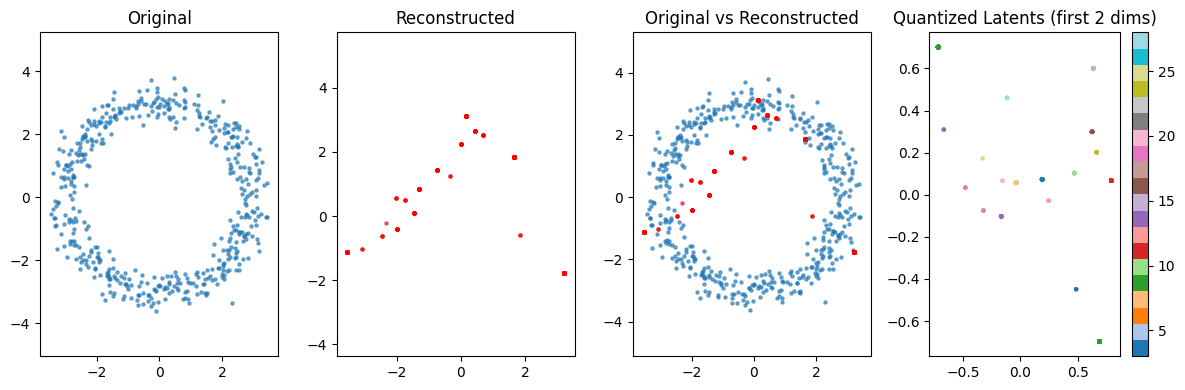

In [ ]:
encoder.eval(); decoder.eval(); quantizer.eval()

with torch.no_grad():
    x_sample = torch.from_numpy(data[:500]).to(device)
    z = encoder(x_sample)
    vq_loss, z_q, perplexity, encodings = quantizer(z)
    indices_eval = encodings.argmax(axis=1)
    x_recon = decoder(z_q)

x_np = x_sample.cpu().numpy()
x_rec_np = x_recon.cpu().numpy()
indices_eval_np = indices_eval.cpu().numpy()  # shape: (500,)

plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.scatter(x_np[:,0], x_np[:,1], s=5, alpha=0.6)
plt.title("Original")
plt.axis('equal')

plt.subplot(1,4,2)
plt.scatter(x_rec_np[:,0], x_rec_np[:,1], s=5, alpha=0.6, c='red')
plt.title("Reconstructed")
plt.axis('equal')

plt.subplot(1,4,3)
plt.scatter(x_np[:,0], x_np[:,1], s=5, alpha=0.6)
plt.scatter(x_rec_np[:,0], x_rec_np[:,1], s=5, alpha=0.6, c='red')
plt.title("Original vs Reconstructed")
plt.axis('equal')

# Latent space
plt.subplot(1,4,4)
z_q_np = z_q.cpu().numpy()
plt.scatter(z_q_np[:,0], z_q_np[:,1], s=5, c=indices_eval_np, cmap='tab20')
plt.title("Quantized Latents (first 2 dims)")
plt.colorbar()

plt.tight_layout()
plt.show()

Compute Codebook Utilization:

During evaluation (or training), collect how many times each code is used.

In [ ]:
with torch.no_grad():
    x_batch = torch.from_numpy(data).to(device)
    z = encoder(x_batch)
    _, _, _, encodings = quantizer(z)  # encodings: (B, K)

    # Count usage per code
    usage = encodings.sum(dim=0).cpu()  # (K,)
    utilization = (usage > 0).float().mean().item()  # fraction of codes used
    print(f"Used {usage.gt(0).sum().item()} / {len(usage)} codes ({utilization*100:.1f}%)")

Used 23 / 32 codes (71.9%)


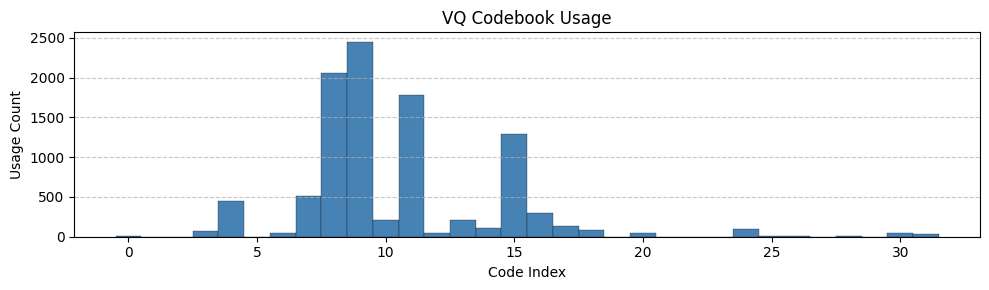

In [ ]:
import matplotlib.pyplot as plt

def plot_codebook_usage(usage, title="Codebook Usage"):
    plt.figure(figsize=(10, 3))
    plt.bar(range(len(usage)), usage, width=1.0, color='steelblue', edgecolor='black', linewidth=0.2)
    plt.xlabel("Code Index")
    plt.ylabel("Usage Count")
    plt.title(title)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# For VQ
_, _, _, encodings = quantizer(z)
usage = encodings.sum(dim=0).cpu()
plot_codebook_usage(usage, "VQ Codebook Usage")

### RVQ training

#### GMM with three clusters

In [ ]:
# Config
latent_dim = 2
codebook_size = 8
num_quantizers = 2
lambda_commit = 0.25


quantizer = RVQ(
    num_quantizers=num_quantizers,
    num_embeddings=codebook_size,
    embedding_dim=latent_dim,
    commitment_cost=lambda_commit
)

encoder = Encoder(latent_dim=latent_dim)
decoder = Decoder(latent_dim=latent_dim)
# discriminator = Discriminator()

models = [encoder, decoder, quantizer] #, discriminator]
for m in models: m.to(device)

# Training
n_epochs = 100
lr=1e-4

# Optimizers
ae_opt = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()) + list(quantizer.parameters()), lr=lr)
# d_opt = torch.optim.Adam(discriminator.parameters(), lr=1e-3)

In [ ]:
encoder.train(); decoder.train(); quantizer.train(); # discriminator.train()

for epoch in range(n_epochs):
  for batch_idx, (x,) in enumerate(dataloader):
      x = x.to(device)  # (B, 2)

      # ----- Autoencoder Forward -----
      z = encoder(x)  # (B, 8)
      vq_loss, z_q, perplexity, encodings = quantizer(z)
      x_recon = decoder(z_q)  # (B, 2)

      # Reconstruction loss
      recon_loss = F.mse_loss(x_recon, x)

      # # ----- Discriminator -----
      # d_opt.zero_grad()
      # real_score = discriminator(x)
      # fake_score = discriminator(x_recon.detach())
      # d_loss = F.softplus(-real_score).mean() + F.softplus(fake_score).mean()
      # d_loss.backward()
      # d_opt.step()

      # # ----- Generator (Autoencoder) with GAN + Feature Matching -----
      # ae_opt.zero_grad()
      # fake_score2 = discriminator(x_recon)
      # g_loss = F.softplus(-fake_score2).mean()

      # # Feature matching: match intermediate features (here: raw output of D)
      # # For simplicity, use discriminator output as "feature"
      # feat_match_loss = F.mse_loss(fake_score2, real_score.detach())

      total_ae_loss = recon_loss + vq_loss
      # total_ae_loss = recon_loss + vq_loss + lambda_gan * g_loss + lambda_feat * feat_match_loss
      total_ae_loss.backward()
      ae_opt.step()

      if epoch % 10 == 0 and batch_idx % 10 == 0:
          print(f"Epoch {epoch}: "
                f"Batch {batch_idx}: "
                f"Recon={recon_loss.item():.4f}, "
                f"perplexity={perplexity.item():.4f}, "
                f"VQ={vq_loss.item():.4f}, "
                # f"D={d_loss.item():.4f}, "
                # f"G={g_loss.item():.4f}"
                )

Epoch 0: Batch 0: Recon=3.8920, perplexity=1.9530, VQ=0.3507, 
Epoch 0: Batch 10: Recon=4.0609, perplexity=1.7904, VQ=0.3200, 
Epoch 0: Batch 20: Recon=4.0789, perplexity=1.8930, VQ=0.2491, 
Epoch 0: Batch 30: Recon=3.7843, perplexity=1.9462, VQ=0.1958, 
Epoch 10: Batch 0: Recon=1.7049, perplexity=2.3257, VQ=89.9589, 
Epoch 10: Batch 10: Recon=1.4958, perplexity=2.2837, VQ=103.0438, 
Epoch 10: Batch 20: Recon=1.5305, perplexity=2.2923, VQ=118.9137, 
Epoch 10: Batch 30: Recon=1.6074, perplexity=2.2623, VQ=118.7526, 
Epoch 20: Batch 0: Recon=1.0978, perplexity=2.6932, VQ=30.0320, 
Epoch 20: Batch 10: Recon=1.0508, perplexity=2.6086, VQ=28.6353, 
Epoch 20: Batch 20: Recon=0.9672, perplexity=2.4062, VQ=26.8946, 
Epoch 20: Batch 30: Recon=1.0648, perplexity=2.4182, VQ=26.3922, 
Epoch 30: Batch 0: Recon=1.0179, perplexity=3.5800, VQ=34.3223, 
Epoch 30: Batch 10: Recon=0.8592, perplexity=3.5119, VQ=37.6414, 
Epoch 30: Batch 20: Recon=0.9504, perplexity=3.7339, VQ=37.8781, 
Epoch 30: Batch 30:

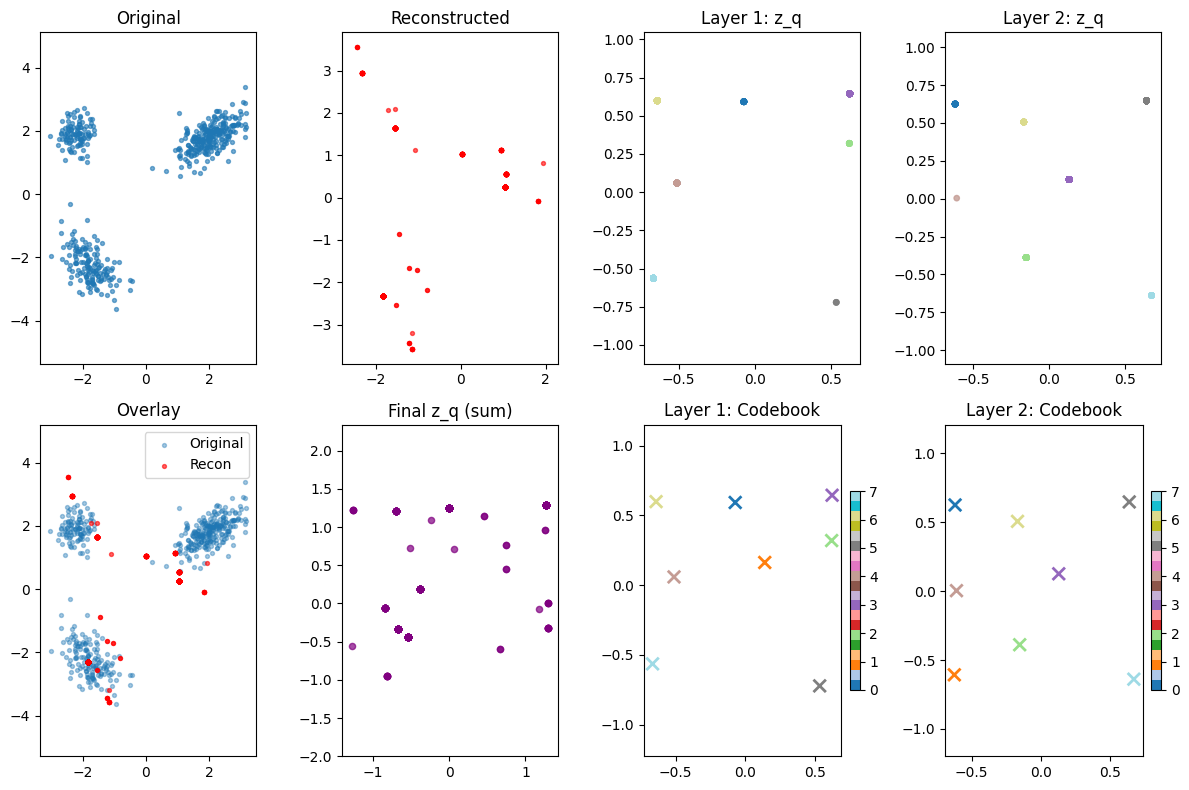

Average Perplexity: 4.27 (max = 8)


In [ ]:
encoder.eval(); decoder.eval(); quantizer.eval()  # quantizer is now RVQ

with torch.no_grad():
    x_sample = torch.from_numpy(data[:500]).to(device)
    z = encoder(x_sample)  # (500, 2)

    # RVQ forward
    vq_loss, z_q, avg_perplexity, all_encodings = quantizer(z)

    # Get per-layer quantized outputs (for visualization)
    residual = z
    z_q_layers = []
    indices_layers = []
    for i, layer in enumerate(quantizer.layers):
        # Re-apply each layer to get its output
        distances = (torch.sum(residual**2, dim=1, keepdim=True)
                    + torch.sum(layer._embedding.weight**2, dim=1)
                    - 2 * torch.matmul(residual, layer._embedding.weight.t()))
        indices = torch.argmin(distances, dim=1)  # (B,)
        z_q_i = layer._embedding(indices)         # (B, D)
        z_q_layers.append(z_q_i)
        indices_layers.append(indices)
        residual = residual - z_q_i

    x_recon = decoder(z_q)

# Move to CPU
x_np = x_sample.cpu().numpy()
x_rec_np = x_recon.cpu().numpy()
z_q_np = z_q.cpu().numpy()

# Get codebooks
codebooks = []
for layer in quantizer.layers:
    codebooks.append(layer._embedding.weight.detach().cpu().numpy())

# ----- Plotting -----
L = len(z_q_layers)
fig, axes = plt.subplots(2, 2 + L, figsize=(6 + 3*L, 8))

# 1. Original
axes[0, 0].scatter(x_np[:,0], x_np[:,1], s=8, alpha=0.6)
axes[0, 0].set_title("Original")
axes[0, 0].axis('equal')

# 2. Reconstructed
axes[0, 1].scatter(x_rec_np[:,0], x_rec_np[:,1], s=8, alpha=0.6, c='red')
axes[0, 1].set_title("Reconstructed")
axes[0, 1].axis('equal')

# 3. Original vs Reconstructed
axes[1, 0].scatter(x_np[:,0], x_np[:,1], s=8, alpha=0.4, label='Original')
axes[1, 0].scatter(x_rec_np[:,0], x_rec_np[:,1], s=8, alpha=0.6, c='red', label='Recon')
axes[1, 0].set_title("Overlay")
axes[1, 0].legend()
axes[1, 0].axis('equal')

# 4. Final quantized latent (sum)
axes[1, 1].scatter(z_q_np[:,0], z_q_np[:,1], s=20, c='purple', alpha=0.7)
axes[1, 1].set_title("Final z_q (sum)")
axes[1, 1].axis('equal')

# 5. Per-layer quantized outputs
for i in range(L):
    z_q_i_np = z_q_layers[i].cpu().numpy()
    indices_i_np = indices_layers[i].cpu().numpy()

    # Quantized vectors from layer i
    axes[0, 2+i].scatter(z_q_i_np[:,0], z_q_i_np[:,1], s=15, c=indices_i_np, cmap='tab20', alpha=0.8)
    axes[0, 2+i].set_title(f"Layer {i+1}: z_q")
    axes[0, 2+i].axis('equal')

    # Codebook for layer i
    cb = codebooks[i]
    sc = axes[1, 2+i].scatter(cb[:,0], cb[:,1], s=80, c=np.arange(cb.shape[0]), cmap='tab20', marker='x', linewidths=2)
    axes[1, 2+i].set_title(f"Layer {i+1}: Codebook")
    axes[1, 2+i].axis('equal')
    plt.colorbar(sc, ax=axes[1, 2+i], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print(f"Average Perplexity: {avg_perplexity.item():.2f} (max = {quantizer.layers[0]._num_embeddings})")



Compute Codebook Utilization:

In [ ]:
with torch.no_grad():
    x_batch = torch.from_numpy(data).to(device)
    z = encoder(x_batch)
    _, _, _, all_encodings = quantizer(z)  # list of (B, K) tensors

    utilizations = []
    for i, enc in enumerate(all_encodings):
        usage = enc.sum(dim=0).cpu()
        utilized = (usage > 0).float().mean().item()
        utilizations.append(utilized)
        print(f"Layer {i}: Used {usage.gt(0).sum().item()} / {len(usage)} codes ({utilized*100:.1f}%)")

Layer 0: Used 8 / 8 codes (100.0%)
Layer 1: Used 7 / 8 codes (87.5%)


In [ ]:
import matplotlib.pyplot as plt

def plot_codebook_usage(usage, title="Codebook Usage"):
    plt.figure(figsize=(10, 3))
    plt.bar(range(len(usage)), usage, width=1.0, color='steelblue', edgecolor='black', linewidth=0.2)
    plt.xlabel("Code Index")
    plt.ylabel("Usage Count")
    plt.title(title)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

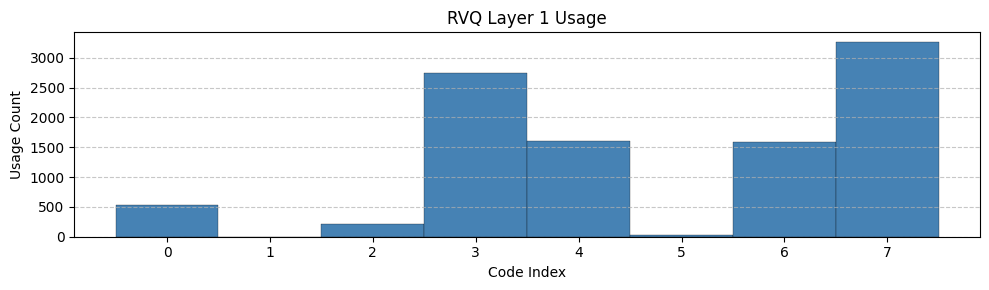

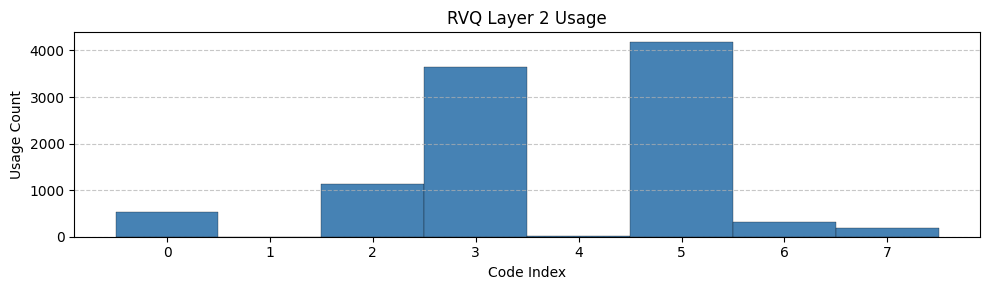

In [ ]:
# For RVQ
for i, enc in enumerate(all_encodings):
    usage = enc.sum(dim=0).cpu()
    plot_codebook_usage(usage, f"RVQ Layer {i+1} Usage")

#### Gaussian Distribution

In [ ]:
# Config
latent_dim = 2
codebook_size = 8
num_quantizers = 2
lambda_commit = 0.25


quantizer = RVQ(
    num_quantizers=num_quantizers,
    num_embeddings=codebook_size,
    embedding_dim=latent_dim,
    commitment_cost=lambda_commit
)

encoder = Encoder(latent_dim=latent_dim)
decoder = Decoder(latent_dim=latent_dim)
# discriminator = Discriminator()

models = [encoder, decoder, quantizer] #, discriminator]
for m in models: m.to(device)

# Training
n_epochs = 100
lr=1e-4

# Optimizers
ae_opt = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()) + list(quantizer.parameters()), lr=lr)
# d_opt = torch.optim.Adam(discriminator.parameters(), lr=1e-3)

In [ ]:
encoder.train(); decoder.train(); quantizer.train(); # discriminator.train()

for epoch in range(n_epochs):
  for batch_idx, (x,) in enumerate(dataloader):
      x = x.to(device)  # (B, 2)

      # ----- Autoencoder Forward -----
      z = encoder(x)  # (B, 8)
      vq_loss, z_q, perplexity, encodings = quantizer(z)
      x_recon = decoder(z_q)  # (B, 2)

      # Reconstruction loss
      recon_loss = F.mse_loss(x_recon, x)

      # # ----- Discriminator -----
      # d_opt.zero_grad()
      # real_score = discriminator(x)
      # fake_score = discriminator(x_recon.detach())
      # d_loss = F.softplus(-real_score).mean() + F.softplus(fake_score).mean()
      # d_loss.backward()
      # d_opt.step()

      # # ----- Generator (Autoencoder) with GAN + Feature Matching -----
      # ae_opt.zero_grad()
      # fake_score2 = discriminator(x_recon)
      # g_loss = F.softplus(-fake_score2).mean()

      # # Feature matching: match intermediate features (here: raw output of D)
      # # For simplicity, use discriminator output as "feature"
      # feat_match_loss = F.mse_loss(fake_score2, real_score.detach())

      total_ae_loss = recon_loss + vq_loss
      # total_ae_loss = recon_loss + vq_loss + lambda_gan * g_loss + lambda_feat * feat_match_loss
      total_ae_loss.backward()
      ae_opt.step()

      if epoch % 10 == 0 and batch_idx % 10 == 0:
          print(f"Epoch {epoch}: "
                f"Batch {batch_idx}: "
                f"Recon={recon_loss.item():.4f}, "
                f"perplexity={perplexity.item():.4f}, "
                f"VQ={vq_loss.item():.4f}, "
                # f"D={d_loss.item():.4f}, "
                # f"G={g_loss.item():.4f}"
                )

Epoch 0: Batch 0: Recon=1.4436, perplexity=1.6857, VQ=0.0326, 
Epoch 0: Batch 10: Recon=1.5045, perplexity=1.7683, VQ=0.0267, 
Epoch 0: Batch 20: Recon=1.5080, perplexity=1.8546, VQ=0.0280, 
Epoch 0: Batch 30: Recon=1.6201, perplexity=2.2670, VQ=0.0291, 
Epoch 10: Batch 0: Recon=0.7691, perplexity=2.5351, VQ=26.5803, 
Epoch 10: Batch 10: Recon=0.8776, perplexity=2.3730, VQ=29.0364, 
Epoch 10: Batch 20: Recon=0.8439, perplexity=2.3917, VQ=24.8508, 
Epoch 10: Batch 30: Recon=0.9934, perplexity=2.4538, VQ=22.5315, 
Epoch 20: Batch 0: Recon=0.9071, perplexity=5.6775, VQ=2.3360, 
Epoch 20: Batch 10: Recon=0.9580, perplexity=5.4204, VQ=2.5545, 
Epoch 20: Batch 20: Recon=0.9665, perplexity=4.9374, VQ=3.0093, 
Epoch 20: Batch 30: Recon=0.9388, perplexity=5.0160, VQ=4.5884, 
Epoch 30: Batch 0: Recon=0.7671, perplexity=3.7387, VQ=21.5034, 
Epoch 30: Batch 10: Recon=0.8910, perplexity=3.6676, VQ=25.1924, 
Epoch 30: Batch 20: Recon=1.0181, perplexity=3.2902, VQ=31.8929, 
Epoch 30: Batch 30: Recon=

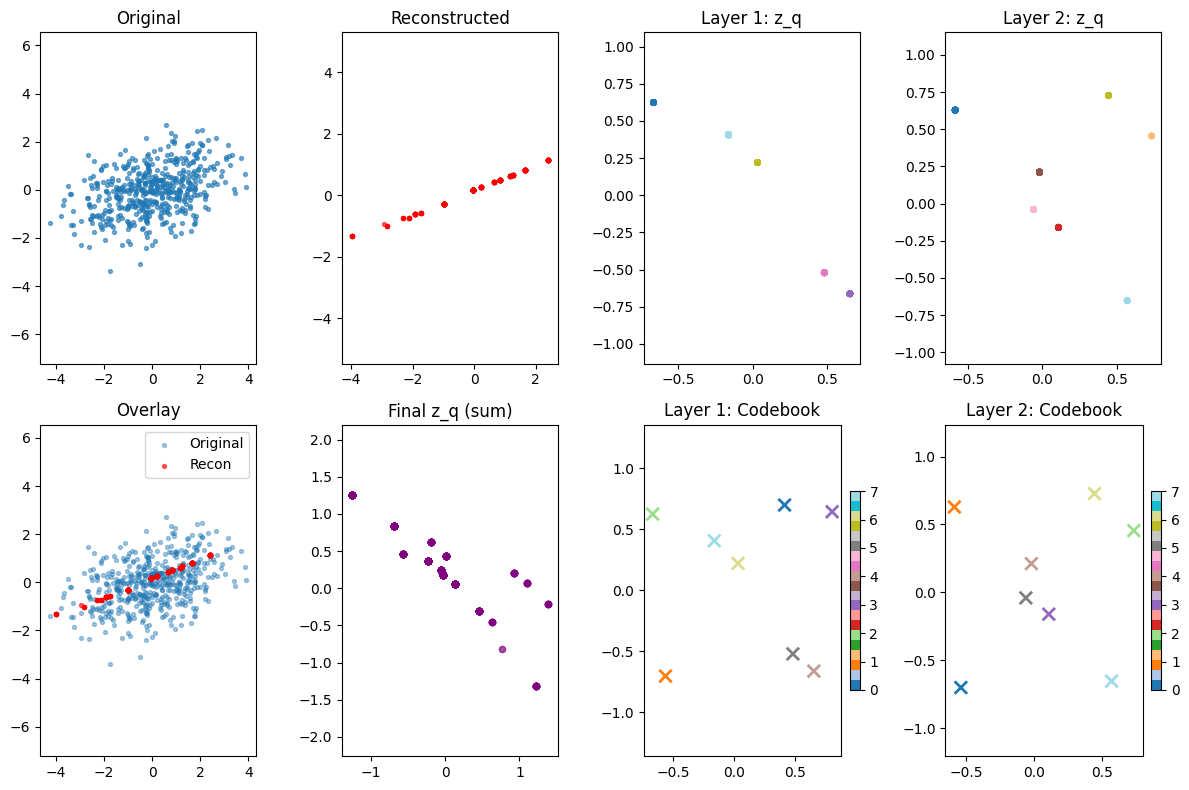

Average Perplexity: 4.12 (max = 8)


In [ ]:
encoder.eval(); decoder.eval(); quantizer.eval()  # quantizer is now RVQ

with torch.no_grad():
    x_sample = torch.from_numpy(data[:500]).to(device)
    z = encoder(x_sample)  # (500, 2)

    # RVQ forward
    vq_loss, z_q, avg_perplexity, all_encodings = quantizer(z)

    # Get per-layer quantized outputs (for visualization)
    residual = z
    z_q_layers = []
    indices_layers = []
    for i, layer in enumerate(quantizer.layers):
        # Re-apply each layer to get its output
        distances = (torch.sum(residual**2, dim=1, keepdim=True)
                    + torch.sum(layer._embedding.weight**2, dim=1)
                    - 2 * torch.matmul(residual, layer._embedding.weight.t()))
        indices = torch.argmin(distances, dim=1)  # (B,)
        z_q_i = layer._embedding(indices)         # (B, D)
        z_q_layers.append(z_q_i)
        indices_layers.append(indices)
        residual = residual - z_q_i

    x_recon = decoder(z_q)

# Move to CPU
x_np = x_sample.cpu().numpy()
x_rec_np = x_recon.cpu().numpy()
z_q_np = z_q.cpu().numpy()

# Get codebooks
codebooks = []
for layer in quantizer.layers:
    codebooks.append(layer._embedding.weight.detach().cpu().numpy())

# ----- Plotting -----
L = len(z_q_layers)
fig, axes = plt.subplots(2, 2 + L, figsize=(6 + 3*L, 8))

# 1. Original
axes[0, 0].scatter(x_np[:,0], x_np[:,1], s=8, alpha=0.6)
axes[0, 0].set_title("Original")
axes[0, 0].axis('equal')

# 2. Reconstructed
axes[0, 1].scatter(x_rec_np[:,0], x_rec_np[:,1], s=8, alpha=0.6, c='red')
axes[0, 1].set_title("Reconstructed")
axes[0, 1].axis('equal')

# 3. Original vs Reconstructed
axes[1, 0].scatter(x_np[:,0], x_np[:,1], s=8, alpha=0.4, label='Original')
axes[1, 0].scatter(x_rec_np[:,0], x_rec_np[:,1], s=8, alpha=0.6, c='red', label='Recon')
axes[1, 0].set_title("Overlay")
axes[1, 0].legend()
axes[1, 0].axis('equal')

# 4. Final quantized latent (sum)
axes[1, 1].scatter(z_q_np[:,0], z_q_np[:,1], s=20, c='purple', alpha=0.7)
axes[1, 1].set_title("Final z_q (sum)")
axes[1, 1].axis('equal')

# 5. Per-layer quantized outputs
for i in range(L):
    z_q_i_np = z_q_layers[i].cpu().numpy()
    indices_i_np = indices_layers[i].cpu().numpy()

    # Quantized vectors from layer i
    axes[0, 2+i].scatter(z_q_i_np[:,0], z_q_i_np[:,1], s=15, c=indices_i_np, cmap='tab20', alpha=0.8)
    axes[0, 2+i].set_title(f"Layer {i+1}: z_q")
    axes[0, 2+i].axis('equal')

    # Codebook for layer i
    cb = codebooks[i]
    sc = axes[1, 2+i].scatter(cb[:,0], cb[:,1], s=80, c=np.arange(cb.shape[0]), cmap='tab20', marker='x', linewidths=2)
    axes[1, 2+i].set_title(f"Layer {i+1}: Codebook")
    axes[1, 2+i].axis('equal')
    plt.colorbar(sc, ax=axes[1, 2+i], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print(f"Average Perplexity: {avg_perplexity.item():.2f} (max = {quantizer.layers[0]._num_embeddings})")

In [ ]:
with torch.no_grad():
    x_batch = torch.from_numpy(data).to(device)
    z = encoder(x_batch)
    _, _, _, all_encodings = quantizer(z)  # list of (B, K) tensors

    utilizations = []
    for i, enc in enumerate(all_encodings):
        usage = enc.sum(dim=0).cpu()
        utilized = (usage > 0).float().mean().item()
        utilizations.append(utilized)
        print(f"Layer {i}: Used {usage.gt(0).sum().item()} / {len(usage)} codes ({utilized*100:.1f}%)")

Layer 0: Used 5 / 8 codes (62.5%)
Layer 1: Used 7 / 8 codes (87.5%)


In [ ]:
import matplotlib.pyplot as plt

def plot_codebook_usage(usage, title="Codebook Usage"):
    plt.figure(figsize=(10, 3))
    plt.bar(range(len(usage)), usage, width=1.0, color='steelblue', edgecolor='black', linewidth=0.2)
    plt.xlabel("Code Index")
    plt.ylabel("Usage Count")
    plt.title(title)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

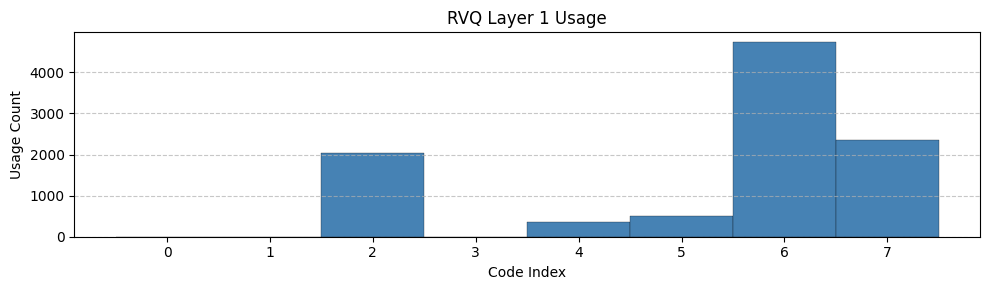

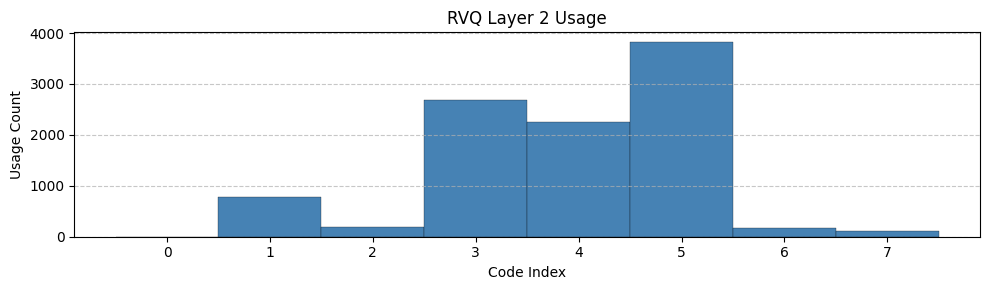

In [ ]:
# For RVQ
for i, enc in enumerate(all_encodings):
    usage = enc.sum(dim=0).cpu()
    plot_codebook_usage(usage, f"RVQ Layer {i+1} Usage")

### ring

In [ ]:
# Config
latent_dim = 2
codebook_size = 8
num_quantizers = 2
lambda_commit = 0.25


quantizer = RVQ(
    num_quantizers=num_quantizers,
    num_embeddings=codebook_size,
    embedding_dim=latent_dim,
    commitment_cost=lambda_commit
)

encoder = Encoder(latent_dim=latent_dim)
decoder = Decoder(latent_dim=latent_dim)
# discriminator = Discriminator()

models = [encoder, decoder, quantizer] #, discriminator]
for m in models: m.to(device)

# Training
n_epochs = 100
lr=1e-4

# Optimizers
ae_opt = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()) + list(quantizer.parameters()), lr=lr)
# d_opt = torch.optim.Adam(discriminator.parameters(), lr=1e-3)

In [ ]:
encoder.train(); decoder.train(); quantizer.train(); # discriminator.train()

for epoch in range(n_epochs):
  for batch_idx, (x,) in enumerate(dataloader):
      x = x.to(device)  # (B, 2)

      # ----- Autoencoder Forward -----
      z = encoder(x)  # (B, 8)
      vq_loss, z_q, perplexity, encodings = quantizer(z)
      x_recon = decoder(z_q)  # (B, 2)

      # Reconstruction loss
      recon_loss = F.mse_loss(x_recon, x)

      # # ----- Discriminator -----
      # d_opt.zero_grad()
      # real_score = discriminator(x)
      # fake_score = discriminator(x_recon.detach())
      # d_loss = F.softplus(-real_score).mean() + F.softplus(fake_score).mean()
      # d_loss.backward()
      # d_opt.step()

      # # ----- Generator (Autoencoder) with GAN + Feature Matching -----
      # ae_opt.zero_grad()
      # fake_score2 = discriminator(x_recon)
      # g_loss = F.softplus(-fake_score2).mean()

      # # Feature matching: match intermediate features (here: raw output of D)
      # # For simplicity, use discriminator output as "feature"
      # feat_match_loss = F.mse_loss(fake_score2, real_score.detach())

      total_ae_loss = recon_loss + vq_loss
      # total_ae_loss = recon_loss + vq_loss + lambda_gan * g_loss + lambda_feat * feat_match_loss
      total_ae_loss.backward()
      ae_opt.step()

      if epoch % 10 == 0 and batch_idx % 10 == 0:
          print(f"Epoch {epoch}: "
                f"Batch {batch_idx}: "
                f"Recon={recon_loss.item():.4f}, "
                f"perplexity={perplexity.item():.4f}, "
                f"VQ={vq_loss.item():.4f}, "
                # f"D={d_loss.item():.4f}, "
                # f"G={g_loss.item():.4f}"
                )

Epoch 0: Batch 0: Recon=4.5087, perplexity=2.6104, VQ=0.0228, 
Epoch 0: Batch 10: Recon=4.6245, perplexity=2.8851, VQ=0.0131, 
Epoch 0: Batch 20: Recon=4.4362, perplexity=3.5569, VQ=0.0089, 
Epoch 0: Batch 30: Recon=4.4465, perplexity=3.2864, VQ=0.0122, 
Epoch 10: Batch 0: Recon=2.5442, perplexity=3.2019, VQ=90.0223, 
Epoch 10: Batch 10: Recon=2.4820, perplexity=3.4743, VQ=97.0976, 
Epoch 10: Batch 20: Recon=2.4045, perplexity=3.3769, VQ=96.1885, 
Epoch 10: Batch 30: Recon=2.1451, perplexity=3.3785, VQ=113.0819, 
Epoch 20: Batch 0: Recon=1.4261, perplexity=4.4100, VQ=116.3819, 
Epoch 20: Batch 10: Recon=1.2688, perplexity=4.5365, VQ=116.2856, 
Epoch 20: Batch 20: Recon=1.4653, perplexity=4.5904, VQ=125.3370, 
Epoch 20: Batch 30: Recon=1.4742, perplexity=4.6313, VQ=121.8812, 
Epoch 30: Batch 0: Recon=1.1889, perplexity=4.5029, VQ=25.2832, 
Epoch 30: Batch 10: Recon=1.1328, perplexity=4.8052, VQ=22.7974, 
Epoch 30: Batch 20: Recon=1.2157, perplexity=4.5754, VQ=23.9789, 
Epoch 30: Batch 3

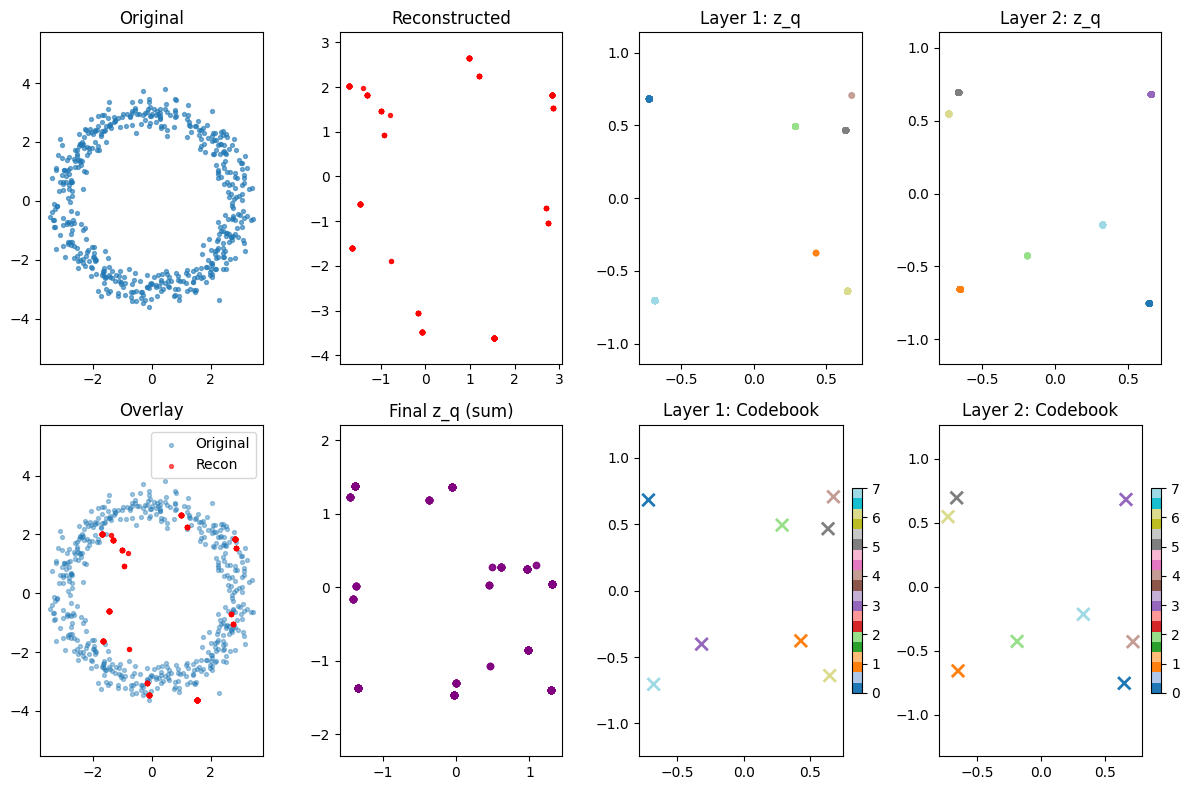

Average Perplexity: 5.16 (max = 8)


In [ ]:
encoder.eval(); decoder.eval(); quantizer.eval()  # quantizer is now RVQ

with torch.no_grad():
    x_sample = torch.from_numpy(data[:500]).to(device)
    z = encoder(x_sample)  # (500, 2)

    # RVQ forward
    vq_loss, z_q, avg_perplexity, all_encodings = quantizer(z)

    # Get per-layer quantized outputs (for visualization)
    residual = z
    z_q_layers = []
    indices_layers = []
    for i, layer in enumerate(quantizer.layers):
        # Re-apply each layer to get its output
        distances = (torch.sum(residual**2, dim=1, keepdim=True)
                    + torch.sum(layer._embedding.weight**2, dim=1)
                    - 2 * torch.matmul(residual, layer._embedding.weight.t()))
        indices = torch.argmin(distances, dim=1)  # (B,)
        z_q_i = layer._embedding(indices)         # (B, D)
        z_q_layers.append(z_q_i)
        indices_layers.append(indices)
        residual = residual - z_q_i

    x_recon = decoder(z_q)

# Move to CPU
x_np = x_sample.cpu().numpy()
x_rec_np = x_recon.cpu().numpy()
z_q_np = z_q.cpu().numpy()

# Get codebooks
codebooks = []
for layer in quantizer.layers:
    codebooks.append(layer._embedding.weight.detach().cpu().numpy())

# ----- Plotting -----
L = len(z_q_layers)
fig, axes = plt.subplots(2, 2 + L, figsize=(6 + 3*L, 8))

# 1. Original
axes[0, 0].scatter(x_np[:,0], x_np[:,1], s=8, alpha=0.6)
axes[0, 0].set_title("Original")
axes[0, 0].axis('equal')

# 2. Reconstructed
axes[0, 1].scatter(x_rec_np[:,0], x_rec_np[:,1], s=8, alpha=0.6, c='red')
axes[0, 1].set_title("Reconstructed")
axes[0, 1].axis('equal')

# 3. Original vs Reconstructed
axes[1, 0].scatter(x_np[:,0], x_np[:,1], s=8, alpha=0.4, label='Original')
axes[1, 0].scatter(x_rec_np[:,0], x_rec_np[:,1], s=8, alpha=0.6, c='red', label='Recon')
axes[1, 0].set_title("Overlay")
axes[1, 0].legend()
axes[1, 0].axis('equal')

# 4. Final quantized latent (sum)
axes[1, 1].scatter(z_q_np[:,0], z_q_np[:,1], s=20, c='purple', alpha=0.7)
axes[1, 1].set_title("Final z_q (sum)")
axes[1, 1].axis('equal')

# 5. Per-layer quantized outputs
for i in range(L):
    z_q_i_np = z_q_layers[i].cpu().numpy()
    indices_i_np = indices_layers[i].cpu().numpy()

    # Quantized vectors from layer i
    axes[0, 2+i].scatter(z_q_i_np[:,0], z_q_i_np[:,1], s=15, c=indices_i_np, cmap='tab20', alpha=0.8)
    axes[0, 2+i].set_title(f"Layer {i+1}: z_q")
    axes[0, 2+i].axis('equal')

    # Codebook for layer i
    cb = codebooks[i]
    sc = axes[1, 2+i].scatter(cb[:,0], cb[:,1], s=80, c=np.arange(cb.shape[0]), cmap='tab20', marker='x', linewidths=2)
    axes[1, 2+i].set_title(f"Layer {i+1}: Codebook")
    axes[1, 2+i].axis('equal')
    plt.colorbar(sc, ax=axes[1, 2+i], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print(f"Average Perplexity: {avg_perplexity.item():.2f} (max = {quantizer.layers[0]._num_embeddings})")

### FSQ Training

In [ ]:
# Config
latent_dim = 2
L = 16
levels = [L, L]

quantizer = FSQ(levels=levels).to(device)

encoder = Encoder(latent_dim=latent_dim).to(device)
decoder = Decoder(latent_dim=latent_dim).to(device)
# discriminator = Discriminator()

models = [encoder, decoder, quantizer] #, discriminator]
for m in models: m.to(device)

# Training
n_epochs = 100
lr=1e-4

# Optimizers
ae_opt = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=lr)
# d_opt = torch.optim.Adam(discriminator.parameters(), lr=1e-3)

print(f"FSQ: {levels} → {quantizer.num_embeddings()} codes, {sum(np.log2(levels)):.0f} bits")

FSQ: [16, 16] → 256 codes, 8 bits


In [ ]:
encoder.train(); decoder.train(); quantizer.train(); # discriminator.train()

for epoch in range(n_epochs):
  for batch_idx, (x,) in enumerate(dataloader):
      x = x.to(device)  # (B, 2)

      # ----- Autoencoder Forward -----
      z = encoder(x)  # (B, D)
      z_q, indices = quantizer(z)  # (B, 2), (B,)
      x_recon = decoder(z_q)  # (B, 2)

      # Reconstruction loss
      recon_loss = F.mse_loss(x_recon, x)

      # Forward
      # # ----- Discriminator -----
      # d_opt.zero_grad()
      # real_score = discriminator(x)
      # fake_score = discriminator(x_recon.detach())
      # d_loss = F.softplus(-real_score).mean() + F.softplus(fake_score).mean()
      # d_loss.backward()
      # d_opt.step()

      # # ----- Generator (Autoencoder) with GAN + Feature Matching -----
      # ae_opt.zero_grad()
      # fake_score2 = discriminator(x_recon)
      # g_loss = F.softplus(-fake_score2).mean()

      # # Feature matching: match intermediate features (here: raw output of D)
      # # For simplicity, use discriminator output as "feature"
      # feat_match_loss = F.mse_loss(fake_score2, real_score.detach())

      total_ae_loss = recon_loss
      total_ae_loss.backward()
      ae_opt.step()

      if epoch % 10 == 0 and batch_idx % 10 == 0:
          print(f"Epoch {epoch}: "
                f"Batch {batch_idx}: "
                f"Recon={recon_loss.item():.4f}, "
                # f"D={d_loss.item():.4f}, "
                # f"G={g_loss.item():.4f}"
                )

Epoch 0: Batch 0: Recon=4.5952, 
Epoch 0: Batch 10: Recon=4.5528, 
Epoch 0: Batch 20: Recon=4.4315, 
Epoch 0: Batch 30: Recon=4.3709, 
Epoch 10: Batch 0: Recon=0.6755, 
Epoch 10: Batch 10: Recon=0.6663, 
Epoch 10: Batch 20: Recon=0.6274, 
Epoch 10: Batch 30: Recon=0.7636, 
Epoch 20: Batch 0: Recon=1.3350, 
Epoch 20: Batch 10: Recon=1.3824, 
Epoch 20: Batch 20: Recon=1.3363, 
Epoch 20: Batch 30: Recon=0.9775, 
Epoch 30: Batch 0: Recon=0.8680, 
Epoch 30: Batch 10: Recon=0.8109, 
Epoch 30: Batch 20: Recon=0.6357, 
Epoch 30: Batch 30: Recon=0.5871, 
Epoch 40: Batch 0: Recon=0.8126, 
Epoch 40: Batch 10: Recon=0.7603, 
Epoch 40: Batch 20: Recon=0.8048, 
Epoch 40: Batch 30: Recon=0.7791, 
Epoch 50: Batch 0: Recon=1.1775, 
Epoch 50: Batch 10: Recon=1.0728, 
Epoch 50: Batch 20: Recon=1.0577, 
Epoch 50: Batch 30: Recon=0.9949, 
Epoch 60: Batch 0: Recon=0.6655, 
Epoch 60: Batch 10: Recon=0.6936, 
Epoch 60: Batch 20: Recon=0.6646, 
Epoch 60: Batch 30: Recon=0.7255, 
Epoch 70: Batch 0: Recon=0.6954

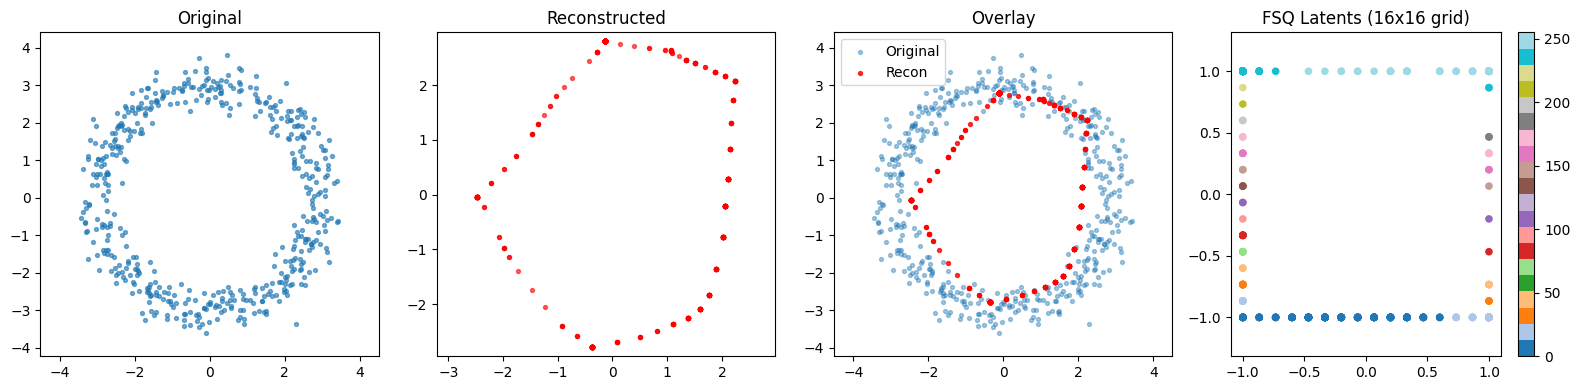

Final MSE: 0.918238


In [ ]:
encoder.eval(); decoder.eval()

with torch.no_grad():
    x_sample = torch.from_numpy(data[:500]).to(device)
    z = encoder(x_sample)
    z_hat, indices = quantizer(z)
    x_recon = decoder(z_hat)

# Move to CPU
x_np = x_sample.cpu().numpy()
x_rec_np = x_recon.cpu().numpy()
z_hat_np = z_hat.cpu().numpy()
indices_np = indices.cpu().numpy()

# Plot
plt.figure(figsize=(16, 4))

# 1. Original
plt.subplot(1, 4, 1)
plt.scatter(x_np[:,0], x_np[:,1], s=8, alpha=0.6)
plt.title("Original")
plt.axis('equal')

# 2. Reconstructed
plt.subplot(1, 4, 2)
plt.scatter(x_rec_np[:,0], x_rec_np[:,1], s=8, alpha=0.6, c='red')
plt.title("Reconstructed")
plt.axis('equal')

# 3. Overlay
plt.subplot(1, 4, 3)
plt.scatter(x_np[:,0], x_np[:,1], s=8, alpha=0.4, label='Original')
plt.scatter(x_rec_np[:,0], x_rec_np[:,1], s=8, alpha=0.8, c='red', label='Recon')
plt.title("Overlay")
plt.legend()
plt.axis('equal')

# 4. Quantized Latents (on FSQ grid)
plt.subplot(1, 4, 4)
plt.scatter(z_hat_np[:,0], z_hat_np[:,1], s=20, c=indices_np, cmap='tab20')
plt.title(f"FSQ Latents ({L}x{L} grid)")
plt.axis('equal')
plt.colorbar()

plt.tight_layout()
plt.show()

print(f"Final MSE: {F.mse_loss(torch.from_numpy(x_rec_np), torch.from_numpy(x_np)).item():.6f}")